# pypylon performance demo

In [19]:
import pypylon.pylon as pylon
import numpy as np
import cv2
import ipywidgets as widgets
from IPython.display import display

In [20]:
camera = pylon.InstantCamera(pylon.FirstFound)

In [21]:
camera.Open()

In [22]:
camera.DeviceModelName.Value

'acA4096-30uc'

In [23]:
camera.UserSetSelector.Value = camera.UserSetDefault.Value
camera.UserSetLoad.Execute()

In [24]:
camera.Height.Value = 2
camera.PixelFormat.Value = "RGB8"

In [25]:
camera.ExposureTime.Value = camera.ExposureTime.Min
camera.Gain.Value = camera.Gain.Max

In [26]:
camera.ResultingFrameRate.Value

1876.172607879925

In [27]:
def speed_test():
    camera.StartGrabbingMax(4901)
    while camera.IsGrabbing():
        with camera.RetrieveResult(1000) as result:
            assert result.GrabSucceeded()
            image = result.Array
    camera.StopGrabbing()

In [28]:
%%timeit -n1 -r1
speed_test()

2.64 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


pypylon had no issues handling 4900 FPS

In [29]:
camera.Close()

## "linescan" capture

the inline capture can be stopped by using jupyter Break [] button.

It will display a fast inline linescan video display

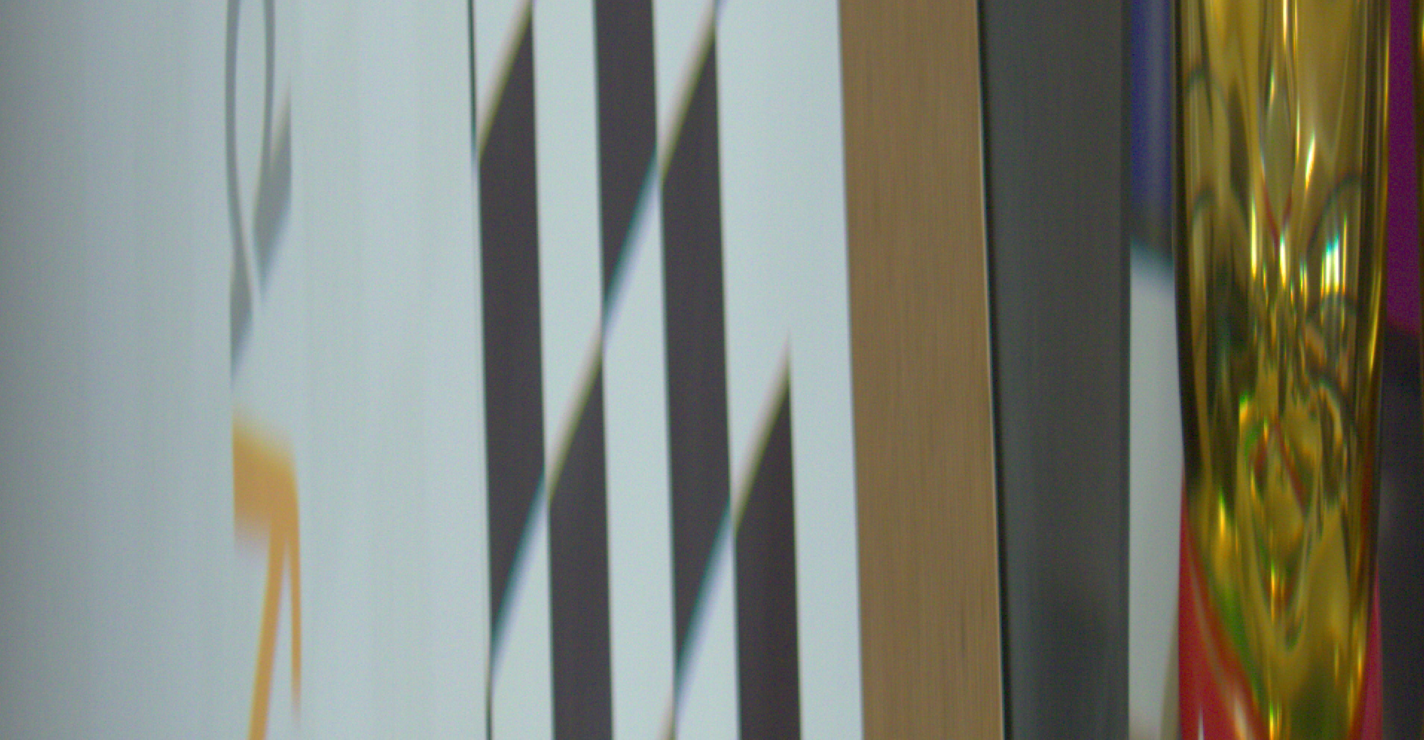

In [34]:
SCANLINE_HEIGHT = 2
VIRTUAL_FRAME_HEIGHT = 1000

camera = pylon.InstantCamera(pylon.FirstFound)
camera.Open()

# setup center scan line
camera.Height.Value = SCANLINE_HEIGHT
camera.Width.Value = camera.Width.Max
camera.CenterX.Value = True
camera.CenterY.Value = True

# setup for
camera.PixelFormat.Value = "BGR8"
camera.Gain.Value = 20
camera.ExposureTime.Value = 900
print("Resulting framerate:", camera.ResultingFrameRate.Value)

# setup jupyter video output 
# create display widget
imagebox = widgets.Image(format='jpg', height=1080//2, width=1920//2)
# display 
display(imagebox)
##

camera.StartGrabbing()

image = np.ones((VIRTUAL_FRAME_HEIGHT, camera.Width.Value,3), dtype=np.uint8)
missing_line = np.ones((SCANLINE_HEIGHT, camera.Width.Value,3), dtype=np.uint8)*255
image_index = 0

try:
    while camera.IsGrabbing():
        for index in range(VIRTUAL_FRAME_HEIGHT // SCANLINE_HEIGHT):
            with camera.RetrieveResult(2000) as result:
                if result.GrabSucceeded():
                    with result.GetArrayZeroCopy() as output_array:
                        image[index * SCANLINE_HEIGHT:index * SCANLINE_HEIGHT + SCANLINE_HEIGHT] = output_array
                else:
                    image[index * SCANLINE_HEIGHT:index * SCANLINE_HEIGHT + SCANLINE_HEIGHT] = missing_line


        imagebox.value = cv2.imencode('.jpg', image)[1].tobytes()

        image_index += 1
except KeyboardInterrupt:
    print( "break grab loop")
    pass

# When everything done, release the capture
camera.StopGrabbing()

camera.Close()

Resulting framerate: 937.207122774133


Image(value=b'', format='jpg', height='540', width='960')

break grab loop


In [33]:
camera.Close()